## **Analysis of JonnyCakes' Trader Joes Rankings**

### *1. Introduction*
JonnyCakes is a YouTuber known for reviewing or creating various types of desserts and baking content. However, he also has a collection of videos reviewing products from different grocery stores, one of them being Trader Joe's. JonnyCakes reviews his products by giving them a score, stating their price, and categorizing them (in accordance to the video's category). In this analysis, I have collected and cleaned raw data from 8 of his Trader Joe's product review videos.

### *2. Data Cleaning Summary*
Data of the reviews have been processed and cleaned in a separate file, containing the following:
- Standardized columns and product names
- Converted review dates to datetime
- Filled in missing prices with external pricing dataset, manually filling in when necessary
- Created 2 new categories (food category and storage type)
- Removed duplicates and  invalid records

In [405]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path

In [406]:
# Load cleaned CSV
DATA = Path("../data/processed")

df = pd.read_csv(DATA / "cleaned_tj_reviews.csv", parse_dates=["date"])

### *3. Dataset Overview*
We will be able to discover possible factors that might have influenced product ratings, such as price, food/storage categories, and date reviewed. The goal is to identify trends and meaningful insights through data analysis and visualization.

### *3.1 Score Distribution*

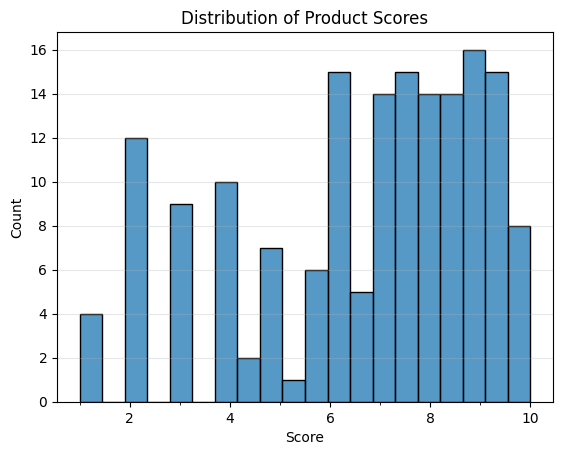

count    167.000000
mean       6.602395
std        2.423503
min        1.000000
25%        5.000000
50%        7.100000
75%        8.550000
max       10.000000
Name: score, dtype: float64

In [407]:
score_plot = sns.histplot(
    df["score"], bins=20
)

score_plot.xaxis.set_major_locator(ticker.MultipleLocator(2))
score_plot.xaxis.set_minor_locator(ticker.MultipleLocator(1))

plt.title("Distribution of Product Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.grid(axis="y", alpha=.3)
plt.show()

df["score"].describe()

**Insight: Score Distribution**

- More products received ratings above a 5/10 compared to below a 5/10, indicating that JonnyCakes generally has favorable opinions of the Trader Joe's products that he reviewed.
- This is indicated from the data's mean score of 6.6/10, an above average score.

### *3.2 Price Distribution*

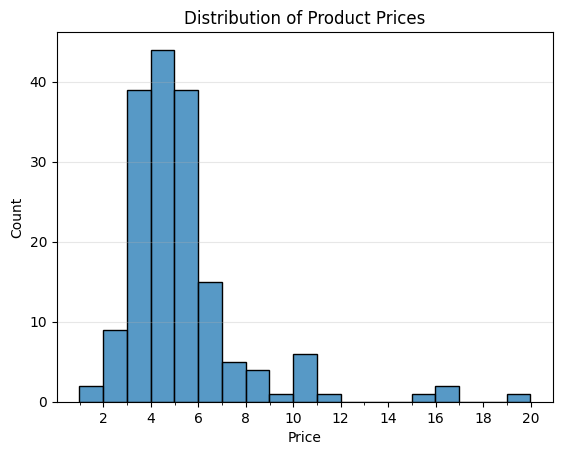

count    169.000000
mean       5.018521
std        2.532054
min        0.990000
25%        3.490000
50%        4.490000
75%        5.490000
max       19.990000
Name: price, dtype: float64

In [408]:
price_plot = sns.histplot(
    df["price"], bins=20, binwidth=1
)

price_plot.xaxis.set_major_locator(ticker.MultipleLocator(2))
price_plot.xaxis.set_minor_locator(ticker.MultipleLocator(1))

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.grid(axis="y", alpha=.3)
plt.show()

df["price"].describe()

**Insight: Price Distribution**

- Most products lie between the \\$3-\\$6 price range, with a few outliers beyond this range, and no products retailing beyond \\$19.99.
- With an average price of \\$5 and half of the products being priced at around \\$4.50, the distribution shows the relative affordability of Trader Joe's items.

### *3.3 Food Category Distribution*

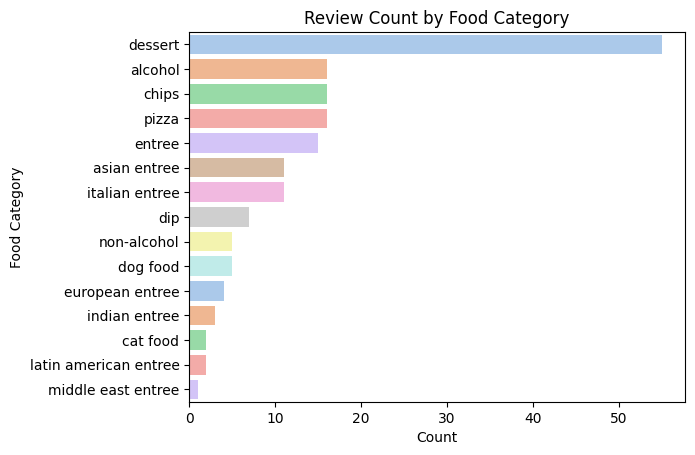

In [409]:
food_cat_counts = df["food_category"].value_counts()

sns.barplot(
    x=food_cat_counts.values,
    y=food_cat_counts.index,
    hue=food_cat_counts.index,
    palette="pastel",
    legend=False
)

plt.title("Review Count by Food Category")
plt.xlabel("Count")
plt.ylabel("Food Category")
plt.show()

**Insight: Food Category Distribution**

- JonnyCakes tended to review desserts the most, with over 50 products reviewed being a type of dessert.
- Alcohol, chips, and pizza were tied for second most reviewed, while many of the entrees weren't reviewed as often.

### *3.4 Storage Type Distribution*

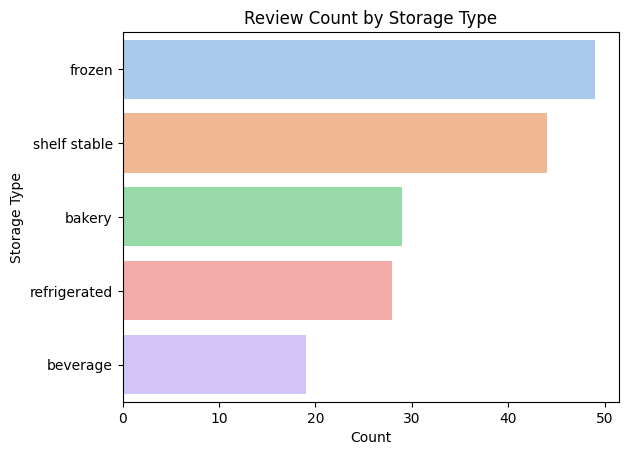

In [410]:
storage_type_counts = df["storage_type"].value_counts()

sns.barplot(
    x=storage_type_counts.values,
    y=storage_type_counts.index,
    hue=storage_type_counts.index,
    palette="pastel",
    legend=False
)

plt.title("Review Count by Storage Type")
plt.xlabel("Count")
plt.ylabel("Storage Type")
plt.show()

**Insight: Storage Type Distribution**

- The most reviewed storage type were frozen products, while beverages were reviewed the least.

### *Overview observations*

From this data, we can deduce that JonnyCakes' most reviewed category is desserts. Ratings are concentrated between 6-9, suggesting that the YouTuber generally rates products favorably. Product prices are right-skewed, with most products costing under \\$6.

## *4. Exploratory Analyses*

### *4.1 Price vs. Ratings*
For this part of the analyses, we will ask the question of "Does a Trader Joe's product's price affect its rating?". The variables we are investigating are as follows:
- Price: We can recall that from section 3.2, most reviewed products were priced around \\$6. Very few products exceeeded \$10.
- Score: Section 3.1 tells us that more than half of all products reviewed had an above average score, with a mean score of 6.6/10. Through this, JonnyCakes is shown to be a high scorer when it comes to Trader Joe's products.

To visualize the above relationship, we can utilize a scatterplot, plotting the price against the score.

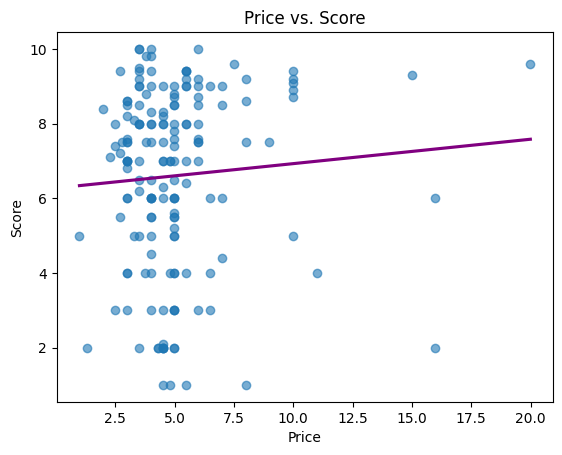

In [411]:
pr_plot = sns.regplot(
    data=df, 
    x="price", 
    y="score",
    line_kws={"color": "purple"},
    scatter_kws={"alpha":0.6},
    ci=None
)

plt.title("Price vs. Score")
plt.xlabel("Price")
plt.ylabel("Score")
plt.show()

**Insight: Price vs. Ratings**

The scatterplot, with the addition of the line of best fit, shows that there is little to no relationship between product price and score. There is much variation across the plot, with no outwardly noticeable trend, however the slope shows a slight upwards tilt as products become more expensive. This may indicate the small presence of a higher score due to higher price relationship.

We can confirm this through calculating the following:

In [412]:
print(f"Correlation coefficient: {df["price"].corr(df["score"])}")

Correlation coefficient: 0.06867586778352099


The Pearson correlation coefficient is 0.069, indicating essentially no linear relationship between price and score.

We can also investigate the relationship further through defined price ranges.

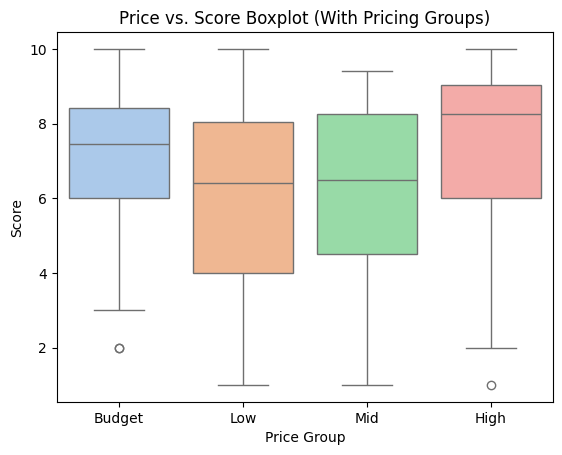

In [413]:
# Divvying all products into 4 equal price sections

df["price_group"] = pd.qcut(
    df["price"],
    q=4,
    labels=["Budget", "Low", "Mid", "High"]
)

df.groupby("price_group")["score"].agg([
    "count",
    "mean",
    "median",
    "std"
])

sns.boxplot(
    x=df["price_group"],
    y=df["score"],
    hue=df["price_group"],
    palette="pastel",
    dodge=False,
    legend=False
)

plt.title("Price vs. Score Boxplot (With Pricing Groups)")
plt.xlabel("Price Group")
plt.ylabel("Score")
plt.show()

**Insight: Price vs. Ratings (continued)**

Although the correlation is somewhat weak, items in the higher price group are indeed shown to have typically higher average ratings. However, the budget price group has the second highest average score, weakening the relationship between price and rating.

Without a clear, strong correlation, we can deduce that the rating of products are quality-driven rather than price-driven.

### *4.2 Food Category Analysis*
All products in the dataset have been identified with a specific food category. The variables we are investigating are as follows:
- Food Category: There are a total of 15 different food categories. From section 3.3, we can see that our top categories are dessert, alcohol, pizza, and chips, while our smallest category would be Latin American entrees.
- Score: Although we have noted that scores were generally better than average for all ratings, these scores may fluctuate depending on the food category.

Our first question to ask is "What are the best and worst overall rated categories?".

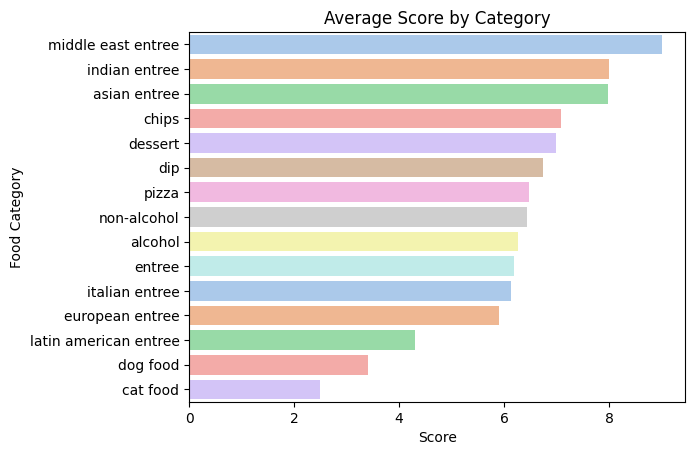

In [415]:
# We can calculate specific averages and other statistical data amongst categories.

category_stats = (
    df.groupby("food_category")
    .agg(
        average_score=("score", "mean"),
        median_score=("score", "median"),
        review_count=("score", "count"),
        score_std=("score", "std")
    )
        .sort_values("average_score", ascending=False)
)

# Let's take a look at the scores by category at face-value with a bar plot.

sns.barplot(
    x=category_stats["average_score"].values,
    y=category_stats["average_score"].index,
    hue=category_stats["average_score"].index,
    palette="pastel",
    legend=False
)

plt.title("Average Score by Category")
plt.xlabel("Score")
plt.ylabel("Food Category")
plt.show()

**Insight: Average Score by Category**

From the above graph, we can see the highest rated food categories were Middle Eastern, Indian, and Asian entrees. However, it is also important to note the number of reviews per category, as these results may be skewed by small sample sizes.

In [416]:
me_count = (df["food_category"] == 'middle east entree').sum()
as_count = (df["food_category"] == 'asian entree').sum()
in_count = (df["food_category"] == 'middle east entree').sum()
print(f"Number of Middle Eastern Entree(s): ", me_count)
print(f"Number of Asian Entree(s): ", as_count)
print(f"Number of Indian Entree(s): ", in_count)

Number of Middle Eastern Entree(s):  1
Number of Asian Entree(s):  11
Number of Indian Entree(s):  1


In the above, we can see that only one Middle Eastern entree was reviewed, and only 3 Indian entrees were reviewed. This reveals that the previous graph is not the best indicator of best food categories vs. worst, as the sample size for each category must also be accounted for when deducing Trader Joe's best reviewed products (according to JonnyCakes).

Rather than just a barplot, a boxplot can reveal to us more information about a food category. For this plot, only categories with more than 10 reviews will be shown, as smaller food categories can produce unstable summary statistics.

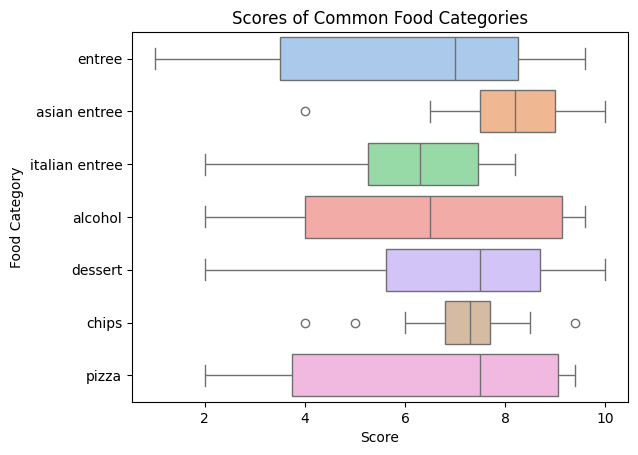

In [417]:
# We are only looking for categories with more than 10 reviews.

valid_categories = food_cat_counts[food_cat_counts >= 10].index
boxplot_df = df[df["food_category"].isin(valid_categories)]

sns.boxplot(
    x=boxplot_df["score"],
    y=boxplot_df["food_category"],
    hue=boxplot_df["food_category"],
    palette="pastel",
    legend=False
)

plt.title("Scores of Common Food Categories")
plt.xlabel("Score")
plt.ylabel("Food Category")
plt.show()

food_cat_stats = category_stats[category_stats.index.isin(valid_categories)]

**Insight: Scores of Common Food Categories**

From the plot and the table, we can say with confidence that Asian entrees do indeed have the best average rating (with an average score of 7.97). This can support its place in the previous barplot, where it also had a high placing. Furthermore, the plot shows that all Asian entrees were rated above a 6/10, making it consistently a good option.

In comparison, Italian entrees have the lowest average rating from the categories shown (roughly 6.14). However, we can also see that the mean score is above a 6/10, meaning that Italian entrees can still be a solid option amongst Trader Joes products.

Another question we could ask is: "Which categories are the most reliable/divisive?"

In [418]:
display(food_cat_stats.round(2))

,average_score,median_score,review_count,score_std
food_category,,,,
asian entree,7.97,8.2,11,1.65
chips,7.09,7.3,16,1.31
dessert,6.99,7.5,54,2.28
pizza,6.48,7.5,16,2.85
alcohol,6.26,6.5,16,2.81
entree,6.18,7.0,15,2.84
italian entree,6.14,6.3,11,1.75


**Insight: Polarizing Food Categories**

From the most common categories, regular entrees seem to have the highest standard deviation, meaning it has the most divisive ratings of the categories listed. This suggests that the quality of entrees reviewed seem to range from both exceptional and disappointing products.

On the other hand, chips are the most reliably rated due to it having the lowest standard deviation. Besides Asian entrees, chips were the only category to all have been rated above a 6/10, as seen in the previous plot. Highly rated chip products are more common, rather than a few standout items.

### *4.3 Storage Type Analysis*
Originally, products only had one category (based off of the video's own categories). However, during cleaning, the categories were re-organized into food category and storage type. In this section, we will look at the storage type. The variables we are investigating are as follows:
- Storage Type: There are a total of 5 different storage types. This includes frozen food, beverages, bakery products, refrigerated food, and shelf stable items.
- Score: An item's score may differ depending on the storage type. Therefore, a question we will investigate is "Does storage type affect perceived quality?".

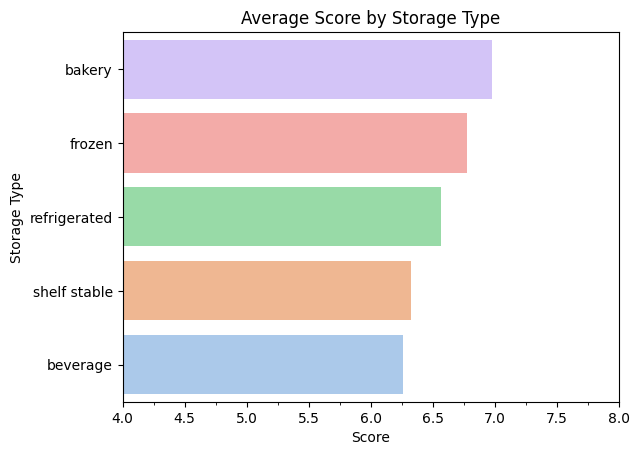

In [419]:
storage_stats = (
    df.groupby("storage_type")
    .agg(
        average_score=("score", "mean"),
        median_score=("score", "median"),
        review_count=("score", "count"),
        score_std=("score", "std")
    )
        .sort_values("average_score", ascending=False)
)

sto_barplot = sns.barplot(
    y=storage_stats["average_score"].index,
    x=storage_stats["average_score"].values,
    hue=storage_stats["average_score"].values,
    palette="pastel",
    legend=False
)

sto_barplot.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

plt.title("Average Score by Storage Type")
plt.xlim(4,8)
plt.xlabel("Score")
plt.ylabel("Storage Type")
plt.show()

**Insight: Average Score by Storage Type**

Many of the storage types seem to have roughly similar averages, hovering anywhere between a 6/10 to 7/10 rating. (The plot's scale has been adjusted to better visualize differences between the types).
From the graph, bakery type products have the highest average score of around 7/10. Therefore we can see that JonnyCakes tended to rate bakery items more favorably.

Beverage type products seem to have the lowest average score of about 6.25/10. 6.25 is still an above average score, but may indicate that beverages might not be the brand's strongest selling point, or could be improved upon.

Like the previous food category analysis, we can dive deeper into our observations with boxplots.

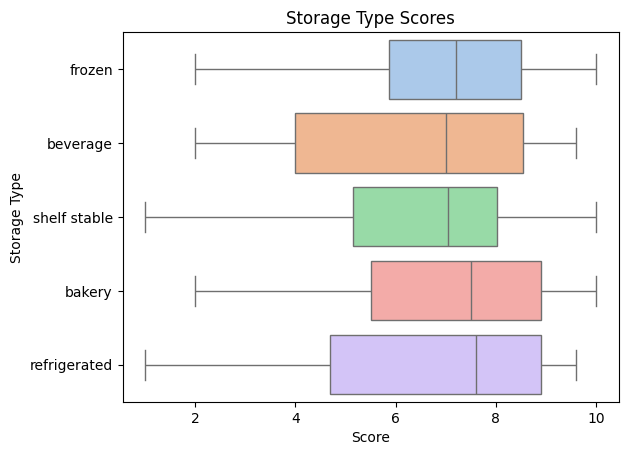

,average_score,median_score,review_count,score_std
storage_type,,,,
bakery,6.979310,7.50,29,2.385728
frozen,6.781250,7.20,48,2.178195
refrigerated,6.570370,7.60,27,2.552799
shelf stable,6.327273,7.05,44,2.540039
beverage,6.257895,7.00,19,2.733398


In [420]:
sns.boxplot(
    x=df["score"],
    y=df["storage_type"],
    hue=df["storage_type"],
    palette="pastel",
    legend=False
)

plt.title("Storage Type Scores")
plt.xlabel("Score")
plt.ylabel("Storage Type")
plt.show()

storage_stats

**Insight: Storage Type Scores**

From the information above, although we know bakery options had the highest average score, refrigerated food items had a barely higher median score of 7.6, even though it had only the third highest average score of 6.57. Differences in median and mean scores for the same category can be due to polarizing ratings for the same category.

Nevertheless, it is not the most divisive storage type. With a standard deviation of 2.73, the beverage type has the most polarizing ratings. As we know beverages had the lowest average score, a high standard deviation could indicate some select items with great or even outstanding quality, but many were teetering on the lower end of the scale.

Interestingly, frozen food items had the lowest standard deviation. From our observations, the storage type was also shown to have the second highest average score, making frozen food options a very solid and consistent choice for Trader Joe's shoppers.

## *5. Key Takeaways*

- Product price showed little correlation with review scores, suggesting that higher-priced items were not consistently rated more favorably.
- Asian entrees consistently ranked among the highest-rated food categories.
- Bakery products earned the highest average ratings from JonnyCakes, suggesting they were among his favorite storage categories.
- Several products in the "budget" price group received ratings comparable to higher priced items (which had the highest average score), highlighting high-value recommendations.

## Important Notes/Limitations

The data must be reviewed as a whole (from all videos), some important actions were taken on my part in the collection of this data:
- This analysis reflects the opinions of a single reviewer (YouTuber JonnyCakes) rather than the broader consumer population. The results should therefore be interpreted as insights into one reviewer's preferences rather than objective measures of product quality.
- In some videos, the products were ranked on a scale of 10 points (10 being the best, and 1 being the worst). Some of the newer videos were ranked on a smaller scale of 5, but these scores have been doubled to be a score out of 10 for consistency.
- Jonny organizes the products in different categories per video, which have been recorded in the original "categories" column of the CSV. However, I re-categorized each item into two types: by storage type and by food category, for the sake of consistency.
- Some products' prices were not stated in the videos. I have filled in the missing prices using online information (comparing date of price changes with video upload date) and [traderjoesprices.com](https://traderjoesprices.com/). However, the accuracy of these new prices are not listed with full confidence. See the 'Resources' section' for more information of supplementary price information/sources.
- Scores were collected a decimal, and prices were collected in USD.